In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import glob as glob

import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import ScalarFormatter

# Aim: Plot profile at given XY location 
- Convert XY coordinates to grid coordinates first 

# Load MITgcm data 

In [2]:
def load_data(run, output, var):

    path_in = "../../../data/lake_zug/{}/{}/".format(run,output)
    fname_data = glob.glob(path_in + var + "*.nc")

    data = xr.open_mfdataset(fname_data, chunks={'X':8,'Y':16}).squeeze()
    data = data.sortby('T').drop_duplicates(dim='T')

    return (data)

In [3]:
run = 'model'
output = 'out2'

u = load_data(run, output, "u").U
v = load_data(run, output, "v").V
theta = load_data(run,output,"theta").Temp

c:\Users\herremha\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
DLL load failed while importing _context: The specified module could not be found.
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


# Convert swiss coordinates to model grid coordinates 

In [4]:
# location in swiss coordinates 
lon_pt = 680084
lat_pt = 218840

# point of origin of model in swiss grid 
XO_SG = 676648
YO_SG = 212416

xmit_pt  =  int(lon_pt) - XO_SG
ymit_pt = int(lat_pt) - YO_SG

print('xcoord on model:{}'.format(xmit_pt ))
print('ycoord on model:{}'.format(ymit_pt ))



xcoord on model:3436
ycoord on model:6424


## Quick plot to check
- Does location look reasonable 

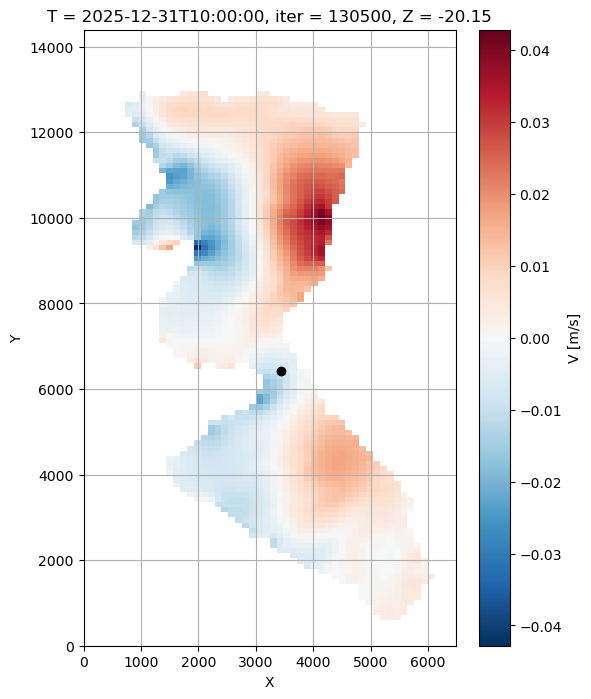

In [7]:
fig, ax = plt.subplots(1,figsize=(6, 8))

v.sel(Z=-20,method="nearest").isel(T=10).plot()
plt.scatter(xmit_pt,ymit_pt,color="k")
plt.grid()

# Plot temperature at XY location 

Text(0.5, 1.0, 'Temp at lon:680084, lat:218840')

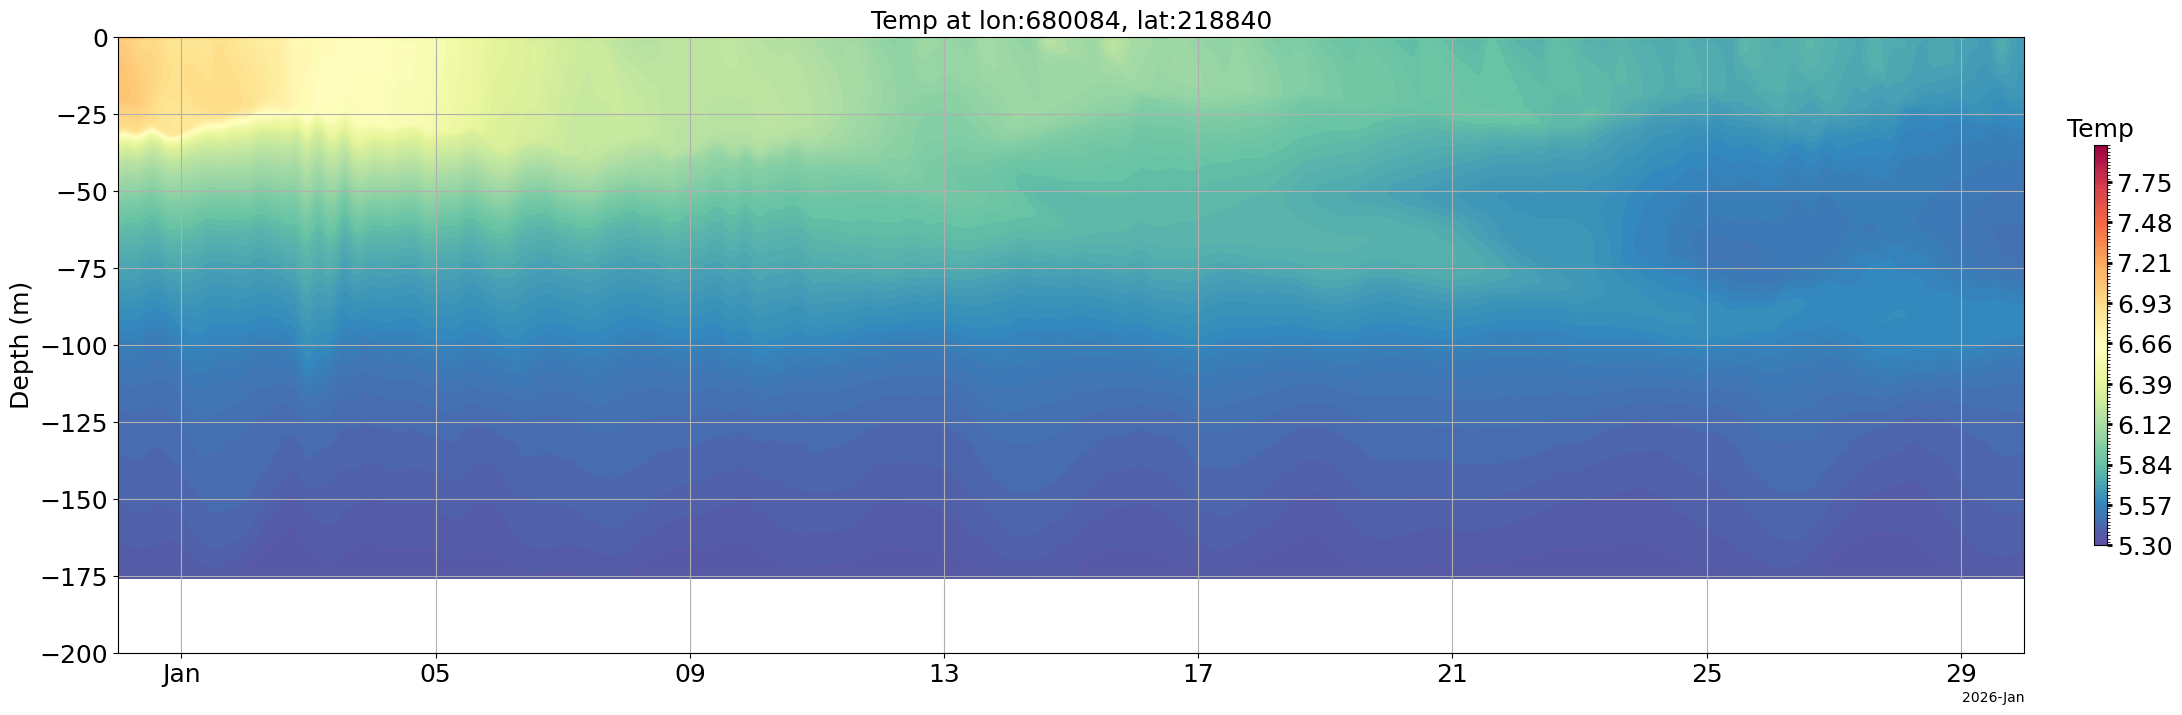

In [6]:
#select mooring location
theta_xy = theta.sel(X=xmit_pt,Y=ymit_pt,method='nearest')

vmin=5.3; vmax= 8
lsize = 18
fig, ax = plt.subplots(1,figsize=(30, 8))
fig1 = theta_xy .plot.contourf(vmin=vmin, vmax=vmax, y='Z', ax=ax,levels=120, cmap='Spectral_r',add_colorbar=False)

# Add horizontal colorbar
cbar = fig.colorbar(fig1, ax=ax, orientation='vertical', pad=0.03, shrink=0.65, aspect=30) #, fraction=0.4, shrink=0.5)

# Adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.set_title('Temp', fontsize=lsize)

ax.tick_params(axis='both', which='major', labelsize=lsize)  # Adjust parameters as needed

plt.ylim(-200,0)
plt.ylabel('Depth (m)',fontsize=lsize)
plt.xlabel('',fontsize=lsize)
plt.grid()
plt.title('Temp at lon:{}, lat:{}'.format(lon_pt,lat_pt),fontsize=lsize)

# Plot V at XY location 

Text(0.5, 1.0, 'V at lon:680084, lat:218840')

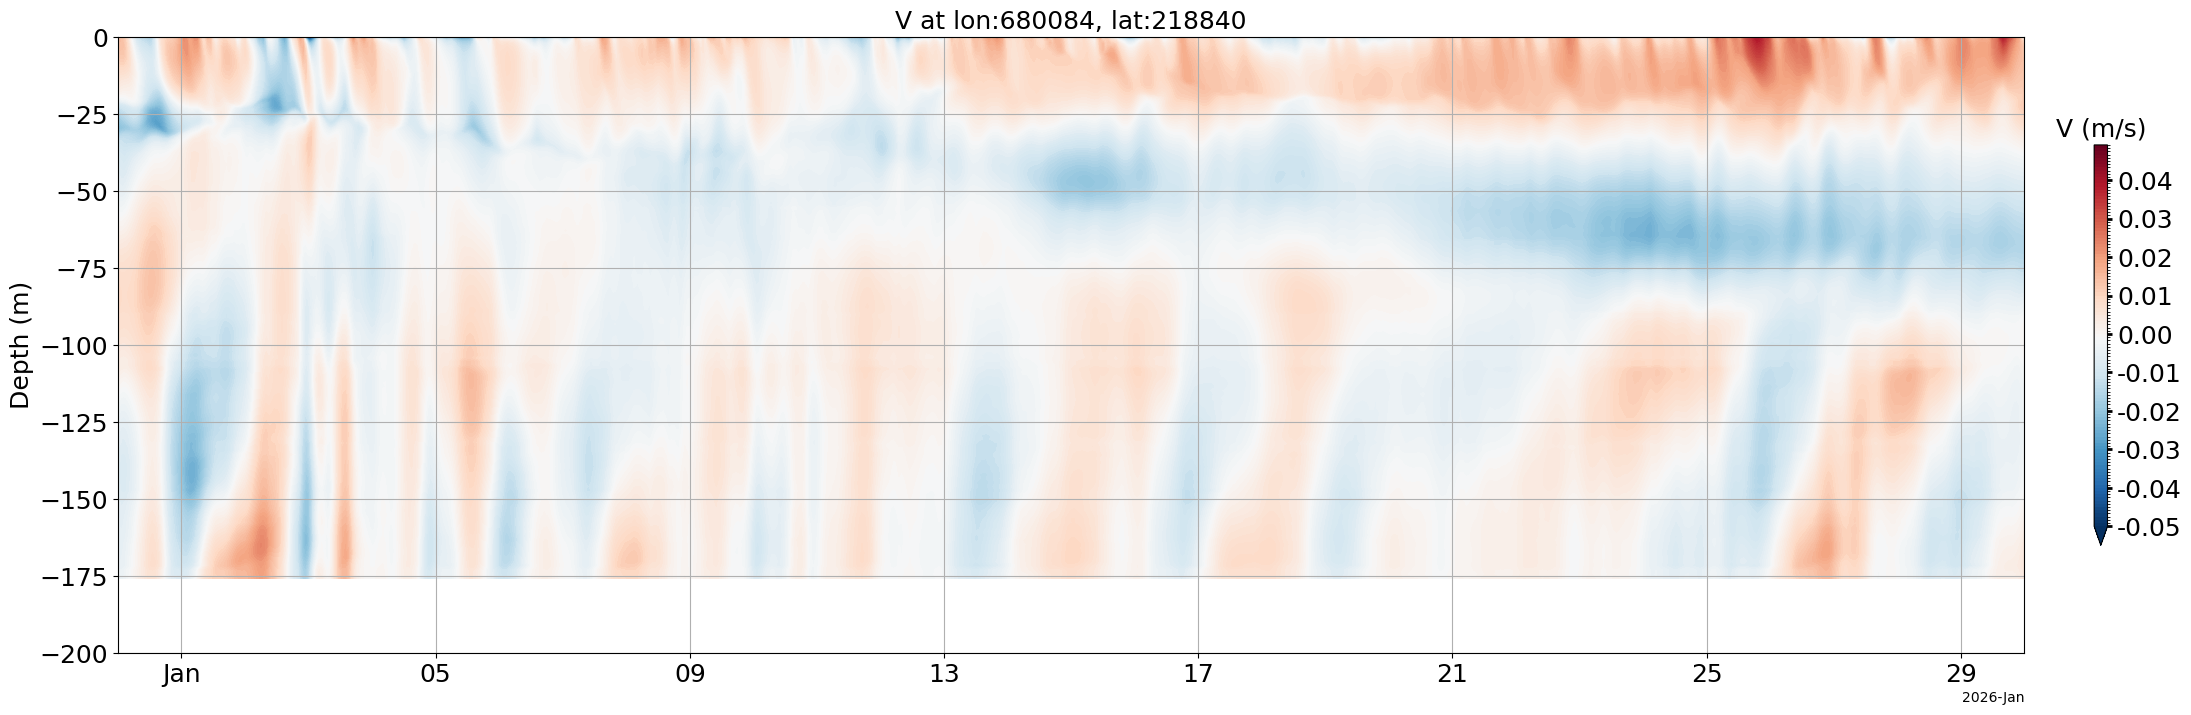

In [8]:
#select mooring location
v_xy = v.sel(X=xmit_pt,Y=ymit_pt,method='nearest')

vmin=-0.05; vmax= 0.05
lsize = 18
fig, ax = plt.subplots(1,figsize=(30, 8))
fig1 = v_xy .plot.contourf(vmin=vmin, vmax=vmax, y='Z', ax=ax,levels=120, cmap='RdBu_r',add_colorbar=False)

# Add horizontal colorbar
cbar = fig.colorbar(fig1, ax=ax, orientation='vertical', pad=0.03, shrink=0.65, aspect=30) #, fraction=0.4, shrink=0.5)

# Adjust the colorbar's tick parameters
cbar.ax.tick_params(labelsize=lsize, width=2)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
cbar.ax.set_title('V (m/s)', fontsize=lsize)

ax.tick_params(axis='both', which='major', labelsize=lsize)  # Adjust parameters as needed

plt.ylim(-200,0)
plt.ylabel('Depth (m)',fontsize=lsize)
plt.xlabel('',fontsize=lsize)
plt.grid()
plt.title('V at lon:{}, lat:{}'.format(lon_pt,lat_pt),fontsize=lsize)